# Tarea 4: EDA multi-fuentes y joins

**Estudiante:** Marcos Devincenzi  
**Unidad:** UT1 — Análisis Exploratorio de Datos

Objetivo: integrar viajes oficiales de NYC Taxi, zonas geográficas y un calendario de eventos; validar los joins y obtener métricas útiles por borough y tipo de día.

> El dataset de viajes tiene aproximadamente tres millones de filas. La primera ejecución puede tardar y requiere conexión a Internet.


In [1]:
# === PASO 1: SETUP ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from pathlib import Path

plt.style.use("default")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ Setup completo para análisis multi-fuentes")


✅ Setup completo para análisis multi-fuentes


## Dependencias

Para leer Parquet se necesita `pyarrow`. Antes de ejecutar el notebook, instalar en el entorno seleccionado:

```bash
uv pip install --python RUTA_DEL_ENTORNO/bin/python pyarrow
```

Para ejecutar el bonus también se necesita `prefect`:

```bash
uv pip install --python RUTA_DEL_ENTORNO/bin/python prefect
```


In [2]:
# === PASO 2: CARGAR DATOS DE MÚLTIPLES FUENTES ===
print("Cargando datos oficiales de NYC Taxi...")

trips_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
zones_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
calendar_url = "https://juanfkurucz.com/ucu-id/ut1/data/calendar.json"

trips = pd.read_parquet(trips_url)
zones = pd.read_csv(zones_url)
calendar = pd.read_json(calendar_url)
calendar["date"] = pd.to_datetime(calendar["date"]).dt.date

print(f"Viajes: {trips.shape[0]:,} filas, {trips.shape[1]} columnas")
print(f"Zonas: {zones.shape[0]:,} filas, {zones.shape[1]} columnas")
print(f"Eventos: {calendar.shape[0]:,} filas, {calendar.shape[1]} columnas")
print(f"Memoria de viajes: {trips.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

display(trips.head())
display(zones.head())
display(calendar.head())


Cargando datos oficiales de NYC Taxi...
Viajes: 3,066,766 filas, 19 columnas
Zonas: 265 filas, 4 columnas
Eventos: 3 filas, 3 columnas
Memoria de viajes: 447.8 MB


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


,date,name,special
0,2022-01-01,New Year,True
1,2022-01-03,Event Day,True
2,2022-01-05,Promo Day,True


In [3]:
# === PASO 3: NORMALIZAR Y PREPARAR DATOS ===
trips.columns = trips.columns.str.lower()
zones.columns = zones.columns.str.lower()
calendar.columns = calendar.columns.str.lower()

trips["pickup_date"] = trips["tpep_pickup_datetime"].dt.date

initial_memory = trips.memory_usage(deep=True).sum() / 1024**2

# Limpiar valores necesarios para los joins y optimizar tipos.
trips["passenger_count"] = trips["passenger_count"].fillna(1)
trips = trips.dropna(subset=["pulocationid", "dolocationid"]).copy()
trips["pulocationid"] = trips["pulocationid"].astype("int16")
trips["dolocationid"] = trips["dolocationid"].astype("int16")
trips["passenger_count"] = trips["passenger_count"].astype("int8")
zones["locationid"] = zones["locationid"].astype("int16")

optimized_memory = trips.memory_usage(deep=True).sum() / 1024**2
savings = (initial_memory - optimized_memory) / initial_memory * 100

print(f"Registros después de limpieza: {len(trips):,}")
print(f"Memoria inicial: {initial_memory:.1f} MB")
print(f"Memoria optimizada: {optimized_memory:.1f} MB")
print(f"Ahorro de memoria: {savings:.1f}%")

print("\nNulos en trips (top 5):")
display(trips.isna().sum().sort_values(ascending=False).head())
print("Nulos en zones:")
display(zones.isna().sum())
print("Nulos en calendar:")
display(calendar.isna().sum())


Registros después de limpieza: 3,066,766
Memoria inicial: 564.8 MB
Memoria optimizada: 509.2 MB
Ahorro de memoria: 9.8%

Nulos en trips (top 5):


airport_fee             71743
congestion_surcharge    71743
store_and_fwd_flag      71743
ratecodeid              71743
passenger_count             0
dtype: int64

Nulos en zones:


locationid      0
borough         1
zone            1
service_zone    2
dtype: int64

Nulos en calendar:


date       0
name       0
special    0
dtype: int64

In [4]:
# === PASO 4: JOIN TRIPS + ZONES ===
trips_with_zones = trips.merge(
    zones,
    left_on="pulocationid",
    right_on="locationid",
    how="left",
    validate="many_to_one",
)

null_after_join = trips_with_zones["borough"].isna().sum()
problematic_ids = trips_with_zones.loc[
    trips_with_zones["borough"].isna(), "pulocationid"
].unique()

print(f"Registros antes del join: {len(trips):,}")
print(f"Registros después del join: {len(trips_with_zones):,}")
print(f"Viajes sin borough asignado: {null_after_join:,}")
print(f"LocationIDs sin coincidencia: {problematic_ids}")
display(trips_with_zones[[
    "pulocationid", "borough", "zone", "trip_distance", "total_amount"
]].head())


Registros antes del join: 3,066,766
Registros después del join: 3,066,766
Viajes sin borough asignado: 1,647
LocationIDs sin coincidencia: [265]


,pulocationid,borough,zone,trip_distance,total_amount
0,161,Manhattan,Midtown Center,0.97,14.30
1,43,Manhattan,Central Park,1.10,16.90
2,48,Manhattan,Clinton East,2.51,34.90
3,138,Queens,LaGuardia Airport,1.90,20.85
4,107,Manhattan,Gramercy,1.43,19.68


In [5]:
# === PASO 5: JOIN CON CALENDARIO ===
trips_complete = trips_with_zones.merge(
    calendar,
    left_on="pickup_date",
    right_on="date",
    how="left",
    validate="many_to_one",
)

trips_complete["is_special_day"] = (
    trips_complete["special"].fillna(False).infer_objects(copy=False)
)

print(f"Registros antes del join: {len(trips_with_zones):,}")
print(f"Registros después del join: {len(trips_complete):,}")
print("\nDistribución de días especiales:")
display(trips_complete["is_special_day"].value_counts())

special_days = trips_complete[trips_complete["is_special_day"]]
if len(special_days) > 0:
    display(special_days[["pickup_date", "special", "borough"]].drop_duplicates())
else:
    print("No hay eventos especiales en el período")

print("\nNulos en columnas clave:")
key_columns = ["borough", "zone", "trip_distance", "total_amount", "is_special_day"]
for col in key_columns:
    print(f"  {col}: {trips_complete[col].isna().sum():,}")


Registros antes del join: 3,066,766
Registros después del join: 3,066,766

Distribución de días especiales:


/tmp/ipykernel_55307/3569255192.py:11: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  trips_complete["special"].fillna(False).infer_objects(copy=False)


is_special_day
False    3066766
Name: count, dtype: int64

No hay eventos especiales en el período

Nulos en columnas clave:
  borough: 1,647
  zone: 40,116
  trip_distance: 0
  total_amount: 0
  is_special_day: 0


In [6]:
# === PASO 6: ANÁLISIS AGREGADO POR BOROUGH ===
borough_analysis = trips_complete.groupby(by="borough").agg({
    "pulocationid": "count",
    "trip_distance": ["mean", "std", "median"],
    "total_amount": ["mean", "std", "median"],
    "fare_amount": "mean",
    "tip_amount": ["mean", "median"],
    "passenger_count": "mean",
}).round(2)

borough_analysis.columns = [
    "num_trips", "avg_distance", "std_distance", "median_distance",
    "avg_total", "std_total", "median_total", "avg_fare",
    "avg_tip", "median_tip", "avg_passengers",
]
borough_analysis = borough_analysis.sort_values(by="num_trips", ascending=False)

borough_analysis["revenue_per_mile"] = (
    borough_analysis["avg_total"] / borough_analysis["avg_distance"]
).round(2)
borough_analysis["tip_rate"] = (
    borough_analysis["avg_tip"] / borough_analysis["avg_fare"] * 100
).round(1)
borough_analysis["market_share"] = (
    borough_analysis["num_trips"] / borough_analysis["num_trips"].sum() * 100
).round(1)

display(borough_analysis)
print(f"Borough con más viajes: {borough_analysis.index[0]}")
print(f"Viajes más largos: {borough_analysis['avg_distance'].idxmax()}")
print(f"Tarifa total promedio más alta: {borough_analysis['avg_total'].idxmax()}")
print(f"Mejor revenue por milla: {borough_analysis['revenue_per_mile'].idxmax()}")


,num_trips,avg_distance,std_distance,median_distance,avg_total,std_total,median_total,avg_fare,avg_tip,median_tip,avg_passengers,revenue_per_mile,tip_rate,market_share
borough,,,,,,,,,,,,,,
Manhattan,2715369,2.88,264.53,1.63,22.49,14.54,19.25,14.78,2.88,2.66,1.35,7.81,19.5,88.6
Queens,286645,12.32,14.42,11.24,67.27,33.64,70.35,49.98,7.85,8.18,1.39,5.46,15.7,9.4
Unknown,40116,7.57,144.96,2.64,38.08,30.41,25.38,26.44,4.82,3.14,1.34,5.03,18.2,1.3
Brooklyn,18076,5.68,70.86,3.45,33.02,22.56,28.64,26.81,2.94,0.60,1.22,5.81,11.0,0.6
Bronx,4162,5.30,6.34,3.10,34.54,33.26,29.70,30.24,0.78,0.00,1.09,6.52,2.6,0.1
EWR,410,1.59,5.68,0.00,104.38,62.75,118.55,87.99,12.44,10.00,1.58,65.65,14.1,0.0
Staten Island,341,11.36,10.21,14.80,62.53,44.92,67.80,48.74,1.32,0.00,1.13,5.50,2.7,0.0


Borough con más viajes: Manhattan
Viajes más largos: Queens
Tarifa total promedio más alta: EWR
Mejor revenue por milla: EWR


In [7]:
# === PASO 7: BOROUGH Y DÍA ESPECIAL ===
borough_day_analysis = trips_complete.groupby(
    by=["borough", "is_special_day"]
).agg({
    "pulocationid": "count",
    "trip_distance": "mean",
    "total_amount": "mean",
}).round(2)
borough_day_analysis.columns = ["num_trips", "avg_distance", "avg_total"]
display(borough_day_analysis)

comparison = trips_complete.groupby(by="is_special_day").agg({
    "trip_distance": "mean",
    "total_amount": "mean",
    "pulocationid": "count",
}).round(2)
comparison.columns = ["Avg Distance", "Avg Amount", "Num Trips"]
comparison = comparison.rename(index={False: "Día Normal", True: "Día Especial"})
display(comparison)

if {"Día Normal", "Día Especial"}.issubset(comparison.index):
    normal_day = comparison.loc["Día Normal"]
    special_day = comparison.loc["Día Especial"]
    distance_change = (
        (special_day["Avg Distance"] - normal_day["Avg Distance"])
        / normal_day["Avg Distance"] * 100
    )
    amount_change = (
        (special_day["Avg Amount"] - normal_day["Avg Amount"])
        / normal_day["Avg Amount"] * 100
    )
    print(f"Cambio en distancia promedio: {distance_change:+.1f}%")
    print(f"Cambio en tarifa promedio: {amount_change:+.1f}%")
else:
    print("No hay ambos tipos de día para calcular una comparación porcentual")


,,num_trips,avg_distance,avg_total
borough,is_special_day,,,
Bronx,False,4162,5.30,34.54
Brooklyn,False,18076,5.68,33.02
EWR,False,410,1.59,104.38
Manhattan,False,2715369,2.88,22.49
Queens,False,286645,12.32,67.27
Staten Island,False,341,11.36,62.53
Unknown,False,40116,7.57,38.08


,Avg Distance,Avg Amount,Num Trips
is_special_day,,,
Día Normal,3.85,27.02,3066766


No hay ambos tipos de día para calcular una comparación porcentual


In [8]:
# === PASO 8: TÉCNICAS PARA DATASETS GRANDES ===
if len(trips_complete) > 50_000:
    sample_size = min(10_000, len(trips_complete) // 10)
    trips_sample = trips_complete.sample(n=sample_size, random_state=42)
else:
    trips_sample = trips_complete.copy()

join_stats = {
    "total_trips": len(trips),
    "matched_zones": trips_complete["borough"].notna().sum(),
    "match_rate": trips_complete["borough"].notna().sum() / len(trips) * 100,
    "unique_zones_used": trips_complete["zone"].nunique(),
    "total_zones_available": len(zones),
    "zone_coverage": trips_complete["zone"].nunique() / len(zones) * 100,
}
display(pd.Series(join_stats, name="valor"))

trips_complete["pickup_hour"] = trips_complete["tpep_pickup_datetime"].dt.hour
hourly_analysis = trips_complete.groupby(by="pickup_hour").agg({
    "pulocationid": "count",
    "total_amount": "mean",
    "trip_distance": "mean",
}).round(2)
hourly_analysis.columns = ["trips_count", "avg_amount", "avg_distance"]

peak_hours = hourly_analysis.sort_values(
    by="trips_count", ascending=False
).head(3)
print("Horas pico:")
display(peak_hours)


total_trips              3.066766e+06
matched_zones            3.065119e+06
match_rate               9.994630e+01
unique_zones_used        2.550000e+02
total_zones_available    2.650000e+02
zone_coverage            9.622642e+01
Name: valor, dtype: float64

Horas pico:


,trips_count,avg_amount,avg_distance
pickup_hour,,,
18,215889,26.43,3.96
17,209493,28.32,4.48
15,196424,27.15,3.67


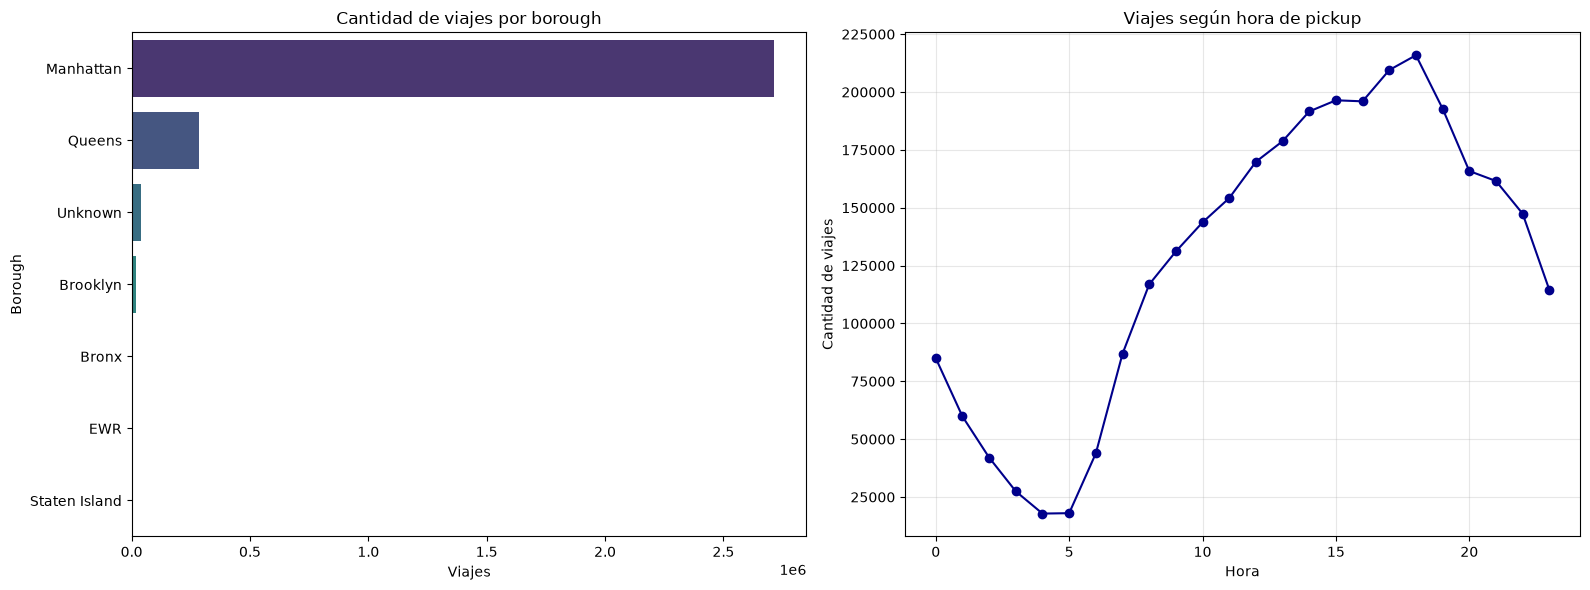

In [9]:
# === VISUALIZACIONES PRINCIPALES ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=borough_analysis.reset_index(),
    y="borough",
    x="num_trips",
    hue="borough",
    legend=False,
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("Cantidad de viajes por borough")
axes[0].set_xlabel("Viajes")
axes[0].set_ylabel("Borough")

axes[1].plot(
    hourly_analysis.index,
    hourly_analysis["trips_count"],
    marker="o",
    color="darkblue",
)
axes[1].set_title("Viajes según hora de pickup")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("Cantidad de viajes")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


,trip_distance,total_amount,fare_amount,tip_amount
trip_distance,1.000,0.016,0.016,0.011
total_amount,0.016,1.000,0.980,0.710
fare_amount,0.016,0.980,1.000,0.590
tip_amount,0.011,0.710,0.590,1.000


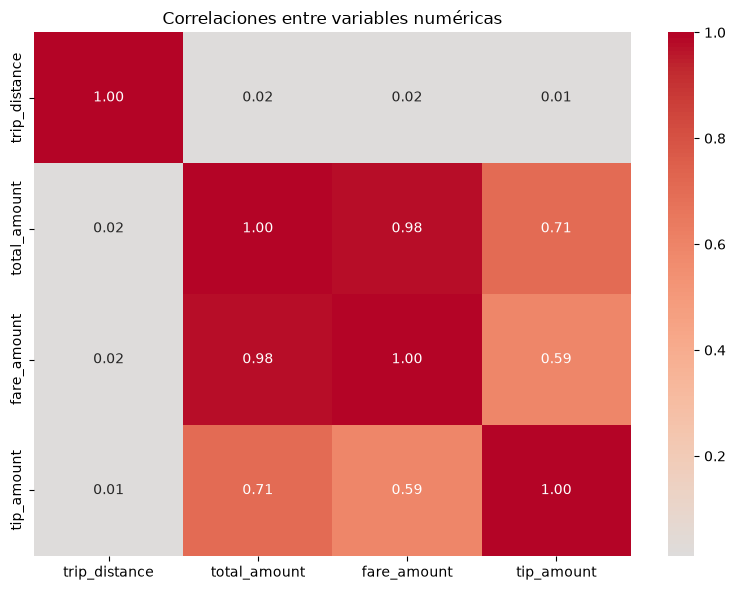

In [10]:
# === PASO 9 OPCIONAL: CORRELACIONES ===
numeric_cols = ["trip_distance", "total_amount", "fare_amount", "tip_amount"]
corr_matrix = trips_complete[numeric_cols].corr()
display(corr_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlaciones entre variables numéricas")
plt.tight_layout()
plt.show()


## Paso 10: preguntas de reflexión

### 1. ¿Qué diferencia hay entre un LEFT JOIN y un INNER JOIN?

Un `LEFT JOIN` conserva todas las filas de la tabla izquierda, aunque no exista una coincidencia en la tabla derecha. En esos casos agrega valores nulos. Un `INNER JOIN` conserva únicamente las filas que tienen una clave coincidente en ambas tablas.

### 2. ¿Por qué usamos LEFT JOIN para trips + zones?

Porque los viajes son la fuente principal y no queremos descartarlos si algún `pulocationid` no aparece en la tabla de zonas. Conservarlos permite medir el porcentaje de claves sin coincidencia y documentar el problema de calidad.

### 3. ¿Qué problemas pueden surgir al unir datos mediante fechas?

Las fechas pueden tener tipos distintos, formatos incompatibles, horas incluidas o zonas horarias diferentes. Antes del join se convirtieron ambas claves al tipo `date`, eliminando la hora para que representaran el mismo nivel temporal.

### 4. ¿Cuál es la ventaja de integrar múltiples fuentes?

La integración agrega contexto que no está presente en una fuente aislada. Los viajes indican qué ocurrió; las zonas permiten saber dónde; y el calendario ayuda a relacionar el comportamiento con eventos especiales.

### 5. ¿Qué insights de negocio proporciona el análisis integrado?

El análisis permite identificar qué borough concentra más viajes, en qué horas aparece la mayor demanda, dónde se obtienen mayores ingresos por milla y si los días especiales cambian la distancia o el importe promedio. Estos resultados pueden apoyar la asignación de vehículos, la planificación de turnos y el seguimiento de zonas con claves faltantes. Las conclusiones concretas deben interpretarse usando los valores impresos por el notebook.


# Bonus: introducción a Prefect

El bonus convierte la carga, el join y el análisis en tareas observables. Las tareas poseen logging y reintentos automáticos ante fallos temporales de red.


In [12]:
# === BONUS 1: SETUP PREFECT ===
import prefect
from prefect import task, flow, get_run_logger

print("✅ Prefect instalado y configurado")
print(f"Versión: {prefect.__version__}")


✅ Prefect instalado y configurado
Versión: 3.8.3


In [13]:
# === BONUS 2: TASKS ===
@task(name="Cargar Datos", retries=2, retry_delay_seconds=3)
def cargar_datos(url: str, tipo: str) -> pd.DataFrame:
    logger = get_run_logger()
    logger.info(f"Cargando {tipo} desde {url}")
    if tipo == "trips":
        data = pd.read_parquet(url)
    elif tipo == "zones":
        data = pd.read_csv(url)
    elif tipo == "calendar":
        data = pd.read_json(url)
        data["date"] = pd.to_datetime(data["date"]).dt.date
    else:
        raise ValueError(f"Tipo de fuente no soportado: {tipo}")
    logger.info(f"{tipo} cargado: {data.shape[0]:,} filas")
    return data


@task(name="Hacer Join Simple")
def hacer_join_simple(trips_df: pd.DataFrame, zones_df: pd.DataFrame) -> pd.DataFrame:
    logger = get_run_logger()
    trips_df = trips_df.copy()
    zones_df = zones_df.copy()
    trips_df.columns = trips_df.columns.str.lower()
    zones_df.columns = zones_df.columns.str.lower()
    resultado = trips_df.merge(
        zones_df,
        left_on="pulocationid",
        right_on="locationid",
        how="left",
        validate="many_to_one",
    )
    logger.info(f"Join completado: {len(resultado):,} registros")
    return resultado


@task(name="Análisis Rápido")
def analisis_rapido(data: pd.DataFrame) -> dict:
    logger = get_run_logger()
    stats = {
        "total_registros": len(data),
        "boroughs": data["borough"].value_counts().head(3).to_dict(),
        "distancia_promedio": round(data["trip_distance"].mean(), 2),
        "tarifa_promedio": round(data["total_amount"].mean(), 2),
    }
    logger.info(f"Análisis completado: {stats}")
    return stats


In [14]:
# === BONUS 3: FLOW PRINCIPAL ===
@flow(name="Pipeline Simple NYC Taxi")
def pipeline_taxi_simple():
    logger = get_run_logger()
    logger.info("Iniciando pipeline simple")

    trips_flow = cargar_datos(trips_url, "trips")
    zones_flow = cargar_datos(zones_url, "zones")
    data_unida = hacer_join_simple(trips_flow, zones_flow)
    resultados = analisis_rapido(data_unida)

    logger.info("Pipeline completado")
    return resultados


In [15]:
# === BONUS 4: EJECUTAR PIPELINE ===
resultado = pipeline_taxi_simple()

print("\nRESULTADOS FINALES DEL FLOW:")
print(f"Total registros: {resultado['total_registros']:,}")
print(f"Distancia promedio: {resultado['distancia_promedio']} millas")
print(f"Tarifa promedio: ${resultado['tarifa_promedio']}")
print("Top 3 boroughs:")
for borough, count in resultado["boroughs"].items():
    print(f"  {borough}: {count:,} viajes")


12:03:17.312 | INFO    | prefect - Starting temporary server on http://127.0.0.1:8718
See https://docs.prefect.io/v3/concepts/server#how-to-guides for more information on running a dedicated Prefect server.

12:03:22.539 | INFO    | Flow run 'unyielding-puma' - Beginning flow run 'unyielding-puma' for flow 'Pipeline Simple NYC Taxi'

12:03:22.543 | INFO    | Flow run 'unyielding-puma' - Iniciando pipeline simple

12:03:22.556 | INFO    | Task run 'Cargar Datos-c51' - Cargando trips desde https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet

12:03:25.011 | INFO    | Task run 'Cargar Datos-c51' - trips cargado: 3,066,766 filas

...

12:03:27.482 | INFO    | Task run 'Análisis Rápido-f12' - Análisis completado: {'total_registros': 3066766, 'boroughs': {'Manhattan': 2715369, 'Queens': 286645, 'Unknown': 40116}, 'distancia_promedio': np.float64(3.85), 'tarifa_promedio': np.float64(27.02)}

12:03:27.485 | INFO    | Task run 'Análisis Rápido-f12' - Finished in state Completed()

12:03:27.486 | INFO    | Flow run 'unyielding-puma' - Pipeline completado

12:03:27.551 | INFO    | Flow run 'unyielding-puma' - Finished in state Completed()


RESULTADOS FINALES DEL FLOW:
Total registros: 3,066,766
Distancia promedio: 3.85 millas
Tarifa promedio: $27.02
Top 3 boroughs:
  Manhattan: 2,715,369 viajes
  Queens: 286,645 viajes
  Unknown: 40,116 viajes


## Reflexiones del bonus

### ¿Qué ventaja tiene `@task` frente a una función normal?

Permite registrar cada ejecución y configurar reintentos. Si una descarga falla temporalmente, Prefect puede repetirla sin reiniciar manualmente todo el pipeline.

### ¿Para qué sirve `@flow`?

Organiza y conecta las tareas que forman el pipeline. También centraliza el seguimiento de su estado, resultados y errores.

### ¿En qué casos reales usaría Prefect?

En reportes diarios, ingestión periódica de datos, actualización de dashboards y pipelines de machine learning que necesitan ejecución programada, logs y recuperación ante fallos.
